# Method B 네트워크 walk-EDA

> 목적: ① 탐색 walk **스텝수 결정**(드리프트 진단) ② **트렌드 키워드 비율** 성공/실패 비교
> ③ **중심성 허브 키워드** ④ 허브 포함이 성공/실패에 따라 다른지.
> 모델: exp10 (`serve.SERVING_EXP`), 오프라인 parquet 기반.

## Phase 0. 셋업

In [33]:
import os, sys
from pathlib import Path
from collections import defaultdict
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib
import networkx as nx
_anchor = Path(globals().get("__vsc_ipynb_file__", ".")).resolve().parent if globals().get("__vsc_ipynb_file__") else Path.cwd()
ROOT = next((str(p) for p in [_anchor, *_anchor.parents] if (p / "CLAUDE.md").exists()), str(_anchor))
sys.path.insert(0, ROOT); os.chdir(ROOT)
matplotlib.rcParams["font.family"] = "Malgun Gothic"; matplotlib.rcParams["axes.unicode_minus"] = False

from src.eval import serve
D = serve._data()
kn = pd.read_parquet("data/processed/hin/keyword_nodes.parquet")
TREND_KW = set(kn.loc[kn["is_trend_keyword"], "keyword"])
prod_succ = dict(zip(D["scores"]["ITEM_NM"], D["scores"]["y_true"]))
SUCC = [p for p in D["prod2kw"] if prod_succ.get(p) == 1]
FAIL = [p for p in D["prod2kw"] if prod_succ.get(p) == 0]
KW_OF = {p: set(k for k, _ in lst) for p, lst in D["prod2kw"].items()}  # 제품→키워드집합
SEEDS = [s for s in ["마라", "흑임자", "로제", "단백질", "딸기", "띠부씰", "감자", "매콤"] if s in D["graph_kw"]]
print("모델:", serve.SERVING_EXP, "| 성공", len(SUCC), "/ 실패", len(FAIL), "| 트렌드키워드", len(TREND_KW))
print("시드:", SEEDS)


모델: exp22_2hop_kw3 | 성공 1197 / 실패 3835 | 트렌드키워드 351
시드: ['마라', '흑임자', '로제', '단백질', '딸기', '띠부씰', '감자', '매콤']


## Phase 0.5 — 성공/실패 판별 진단 (Confusion Matrix & 1·3사분면 분석)

> 차분 서브망 분석에 앞서, exp22가 **실제 라벨(`y_true`) × 모델 예측(`pred_success_prob ≥ THR`)**로
> 제품을 어떻게 가르는지 먼저 진단한다.
>
> - **Cell 1**: 마스터 테이블(`CMDF`) 구성 + Confusion Matrix — 오분류 두 칸(FN·FP) 중 어디가 큰지.
> - **Cell 2·3**: **1사분면 TP**(실성공·예측성공 = 고순도 성공) · **3사분면 TN**(실실패·예측실패 = 고순도 실패)
>   제품을 중분류·도메인 분포 + 매출/좋아요합 순위로 분석.
> - 크기 지표: 세븐 POS = `sales_30d_amt`(매출), 인스타기반(CU·GS25·세븐인스타) = 좋아요합(세븐인스타는 브릿지 경유).

### 임계값(THR) 선택 근거 — 왜 test set 임계(0.766)인가

모델 평가식(`src/eval/success_predictor.compute_metrics`)에서 **PR-AUC·AUC-ROC는 임계가 필요 없는(threshold-free) 연속 확률 지표**이고, **F1만 best-threshold 방식** — 각 split 점수에서 F1이 최대가 되는 임계를 따로 탐색 — 으로 구한다. 그 결과:

| split | F1-최적 임계 | F1 | PR-AUC |
|---|---|---|---|
| train | 0.664 | 0.768 | 0.792 |
| val | 0.755 | 0.669 | 0.742 |
| **test** | **0.766** | 0.660 | **0.683** |

여기서는 `THR = 0.766` (**test split의 F1-최적 임계**)를 전체 제품 예측에 **전이(transfer) 적용**한다. 이유:

1. **모델이 실제로 평가·운영된 임계**다. 임의의 0.5(base rate 0.238 대비 과관대 → FP 폭증, precision 0.58로 왜곡)가 아니라, 모델이 학습·평가 과정에서 도달한 운영점.
2. **전체셋에서 임계를 재계산하면 순환·누수**가 된다. 전체(train 70% 포함)는 모델이 라벨을 본 train 노드가 섞여 있어, 그 위에서 임계를 다시 맞추면 "자기 데이터에 튜닝"한 값이라 분포가 낙관 편향(전체 PR-AUC 0.767 > test 0.683). test에서 정한 임계를 **밖에서 가져와 전이**하는 게 누수 없는 운영점.
3. 임계 후보들(0.66~0.79)이 F1 0.71~0.73으로 **사실상 차이 없어** 선택 민감도가 낮음 → 모델 자신의 평가 임계를 쓰는 게 가장 방어 가능.

> **주의**: 전체셋(train+test 혼합) confusion은 *모델 성능 측정*이 아니라 *전체 제품에 점수를 흘렸을 때의 예측 분포*를 보기 위한 것이다. 모델 성능 지표는 test split 기준 **PR-AUC 0.683**(랜덤 0.236의 2.9배). 또한 1·3사분면을 pred로 정의하는 건 약간 순환적이므로, 차분 서브망의 고순도 모집단은 `y_true` 직접 필터를 우선한다.


In [ ]:
# [Phase 0.5 · Cell 1] 성공/실패 판별 진단 — 마스터 테이블 + Confusion Matrix
# 모델(exp22)의 실제 라벨(y_true) × 예측(pred_success_prob >= THR) 교차.
# 크기 지표: 세븐 POS = 매출(sales_30d_amt) / 인스타기반(CU·GS25·세븐인스타) = 좋아요합.
import os, sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib, matplotlib.pyplot as plt
try:
    from IPython.display import display
except Exception:
    display = print
_anchor = Path(globals().get("__vsc_ipynb_file__", ".")).resolve().parent if globals().get("__vsc_ipynb_file__") else Path.cwd()
ROOT = next((str(p) for p in [_anchor, *_anchor.parents] if (p / "CLAUDE.md").exists()), str(_anchor))
sys.path.insert(0, ROOT); os.chdir(ROOT)
matplotlib.rcParams["font.family"] = "Malgun Gothic"; matplotlib.rcParams["axes.unicode_minus"] = False

EXP = "exp22_2hop_kw3"
THR = 0.766   # ★ test split F1-최적 임계(metrics.json) 전이 적용 — 헤더 마크다운 '임계값 선택 근거' 참조
              #    (0.5는 base rate 0.238 대비 과관대 → FP 폭증으로 precision 왜곡)

def _norm_id(x):
    try:
        return str(int(float(x)))
    except (ValueError, TypeError):
        return str(x)

# 1) 모델 스코어 (실제 라벨 y_true + 예측확률)
sc = pd.read_parquet(f"experiments/results/{EXP}/learned_product_scores.parquet")
sc["_id"] = sc["ITEM_CD"].map(_norm_id)
# 2) 제품 노드 (편의점명·ITEM_NM). scores에도 ITEM_NM이 있으므로 드롭 후 product_nodes 것 사용
#    (product_nodes.ITEM_NM = CU/GS25는 정규화명 → 좋아요 조인 키)
pn = pd.read_parquet("data/processed/hin/product_nodes.parquet", columns=["ITEM_CD", "ITEM_NM", "편의점명"])
pn["_id"] = pn["ITEM_CD"].map(_norm_id)
df = sc.drop(columns=["ITEM_NM"]).merge(pn[["_id", "ITEM_NM", "편의점명"]], on="_id", how="left")
# 3) 세븐 POS 중분류·매출
pos = pd.read_parquet("data/processed/pos_product_features.parquet",
                      columns=["ITEM_CD", "ITEM_MDDV_NM", "sales_30d_amt"])
pos["_id"] = pos["ITEM_CD"].map(_norm_id)
df = df.merge(pos[["_id", "ITEM_MDDV_NM", "sales_30d_amt"]], on="_id", how="left").rename(columns={"ITEM_MDDV_NM": "중분류"})
# 4) 좋아요합 — 인스타 기반(중분류 없는) 제품. CU/GS25는 (편의점명·정규화명) 직접, 세븐인스타는 브릿지 경유
ig = pd.read_parquet("data/processed/instagram_engagement_with_keywords.parquet")
ig["좋아요 수"] = ig["좋아요 수"].clip(lower=0)  # -1: 인스타 좋아요수 비공개 sentinel → 0 처리 (3행)
likes_cv = ig.groupby(["편의점명", "정규화명"])["좋아요 수"].sum().rename("좋아요합").reset_index()
df = df.merge(likes_cv, left_on=["편의점명", "ITEM_NM"], right_on=["편의점명", "정규화명"], how="left").drop(columns=["정규화명"])
mask_7i = df["중분류"].isna() & (df["편의점명"] == "세븐일레븐")
if mask_7i.any():
    br = pd.read_parquet("data/processed/seven_eleven_product_master.parquet", columns=["ITEM_CD", "인스타_정규화명"])
    id2norm = dict(zip(br["ITEM_CD"].map(_norm_id), br["인스타_정규화명"]))
    likes7 = ig[ig["편의점명"] == "세븐일레븐"].groupby("정규화명")["좋아요 수"].sum()
    df.loc[mask_7i, "좋아요합"] = df.loc[mask_7i, "_id"].map(id2norm).map(likes7)
# 5) 도메인 + 예측 라벨 + 사분면
df["도메인"] = np.where(df["중분류"].notna(), "세븐POS",
                np.where(df["편의점명"] == "세븐일레븐", "세븐인스타", df["편의점명"]))
df["pred_label"] = (df["pred_success_prob"] >= THR).astype(int)
def _quad(yt, yp):
    if yt == 1 and yp == 1: return "TP(1사분면)"
    if yt == 1 and yp == 0: return "FN(2사분면)"
    if yt == 0 and yp == 0: return "TN(3사분면)"
    return "FP(4사분면)"
df["사분면"] = [_quad(a, b) for a, b in zip(df["y_true"], df["pred_label"])]
CMDF = df   # ▶ 다운스트림 셀(Cell 2·3)에서 사용

# ── Confusion Matrix ──
TP = int(((df.y_true == 1) & (df.pred_label == 1)).sum()); FN = int(((df.y_true == 1) & (df.pred_label == 0)).sum())
FP = int(((df.y_true == 0) & (df.pred_label == 1)).sum()); TN = int(((df.y_true == 0) & (df.pred_label == 0)).sum())
tot = TP + FN + FP + TN
M = np.array([[FN, TP], [TN, FP]])   # 행=실제(성공/실패), 열=예측(실패/성공) → 1사분면 우상
cell_lab = [["FN(2사분면)", "TP(1사분면)"], ["TN(3사분면)", "FP(4사분면)"]]
fig, ax = plt.subplots(figsize=(5.6, 4.6)); im = ax.imshow(M, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["예측 실패", "예측 성공"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["실제 성공", "실제 실패"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cell_lab[i][j]}\n{M[i, j]:,}\n({M[i, j] / tot * 100:.1f}%)", ha="center", va="center",
                color="white" if M[i, j] > M.max() * 0.5 else "black", fontsize=10)
ax.set_xlabel("모델 예측"); ax.set_ylabel("실제 라벨")
ax.set_title(f"Confusion Matrix (exp22, THR={THR} = test F1-최적, n={tot:,})")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04); plt.tight_layout(); plt.show()

prec = TP / (TP + FP + 1e-9); rec = TP / (TP + FN + 1e-9); f1 = 2 * prec * rec / (prec + rec + 1e-9); acc = (TP + TN) / tot
print(f"정확도 {acc:.3f} | Precision {prec:.3f} | Recall {rec:.3f} | F1 {f1:.3f}  (THR={THR}, 전체 train+test)")
print(f"▶ 오분류(실패한 두 라벨) 비교:  FN(실성공·예측실패) {FN:,}  vs  FP(실실패·예측성공) {FP:,}"
      f"  →  '{'FN' if FN > FP else 'FP'}'이 더 많음")
print(f"[참고] 모델 성능지표는 test split 기준 PR-AUC 0.683 (threshold-free) — 위 전체셋 confusion은 예측 '분포'용")
print("\n도메인 분포: " + " / ".join(f"{kk}={vv}" for kk, vv in df["도메인"].value_counts().items()))

1·3사분면 제품: 4,335  (TP 881 / TN 3,454)

=== 세븐 중분류별 1·3사분면 분포 (상위 20) ===


분류,TN(고순도실패),TP(고순도성공),합계
중분류,,,
와인,238,3,241
노벨티,161,42,203
비스킷류,144,41,185
양주,135,6,141
스낵류,67,53,120
초콜릿,74,37,111
젤리류,72,35,107
간식빵,31,61,92
도시락,41,35,76


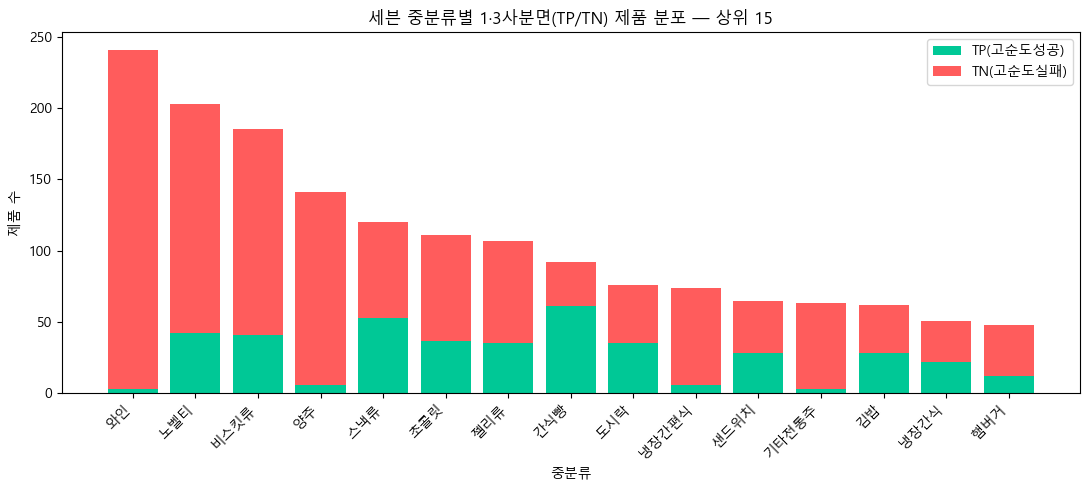

=== 인스타 도메인별 1·3사분면 분포 ===


분류,TN(고순도실패),TP(고순도성공)
도메인,,
CU,932,112
GS25,857,46
세븐인스타,106,12


In [35]:
# [Phase 0.5 · Cell 2] 1·3사분면(TP·TN) 모집단 — 중분류/도메인별 분포
# Q1=TP(실성공·예측성공)=고순도 성공, Q3=TN(실실패·예측실패)=고순도 실패.
# 라벨과 모델이 일치한 깨끗한 집단 → 차분 서브망(A_succ/A_fail) 입력 후보.
q13 = CMDF[CMDF["사분면"].isin(["TP(1사분면)", "TN(3사분면)"])].copy()
q13["분류"] = np.where(q13["y_true"] == 1, "TP(고순도성공)", "TN(고순도실패)")
print(f"1·3사분면 제품: {len(q13):,}  "
      f"(TP {int((q13['y_true'] == 1).sum()):,} / TN {int((q13['y_true'] == 0).sum()):,})")

# ── 세븐 중분류별 ──
sev = q13[q13["중분류"].notna()]
piv = sev.pivot_table(index="중분류", columns="분류", values="_id", aggfunc="count", fill_value=0)
piv["합계"] = piv.sum(axis=1)
piv = piv.sort_values("합계", ascending=False)
print("\n=== 세븐 중분류별 1·3사분면 분포 (상위 20) ===")
display(piv.head(20))

top = piv.drop(columns="합계").head(15)
fig, ax = plt.subplots(figsize=(11, 5)); bottom = np.zeros(len(top))
for col, color in [("TP(고순도성공)", "#00C896"), ("TN(고순도실패)", "#FF5C5C")]:
    if col in top.columns:
        ax.bar(top.index, top[col], bottom=bottom, label=col, color=color)
        bottom += top[col].values
ax.set_title("세븐 중분류별 1·3사분면(TP/TN) 제품 분포 — 상위 15")
ax.set_xlabel("중분류"); ax.set_ylabel("제품 수")
plt.xticks(rotation=45, ha="right"); ax.legend(); plt.tight_layout(); plt.show()

# ── 인스타 도메인별 ──
ins = q13[q13["중분류"].isna()]
piv2 = ins.pivot_table(index="도메인", columns="분류", values="_id", aggfunc="count", fill_value=0)
print("=== 인스타 도메인별 1·3사분면 분포 ===")
display(piv2)

=== 세븐 1·3사분면 매출 상위 30 ===


,ITEM_NM,중분류,pred_success_prob,분류,매출
2783,하정우)마키키쇼비뇽블랑750ml,와인,0.979,TP,"18,326만원"
1054,신동엽)블랙서클위스키700ml,양주,0.954,TP,"9,672만원"
1483,CSR)텍스트북나파까버네에디션750ml,와인,0.875,TP,"5,473만원"
2797,롯데)NEW참치마요네즈삼각,삼각김밥,0.961,TP,"4,061만원"
2722,롯데)아몬드빼빼로37g(테디베어),비스킷류,0.955,TP,"3,942만원"
2615,롯데)초코필드빼빼로53g(테디베어),비스킷류,0.958,TP,"3,935만원"
1151,한도초과)의성마늘햄&고추장불고기,도시락,0.970,TP,"3,895만원"
1831,그린)맛장우맛자랑 반반제육,도시락,0.981,TP,"3,348만원"
2462,그린)뷔페한상 11찬도시락,도시락,0.951,TP,"3,314만원"
2721,롯데)초코빼빼로54g(테디베어),비스킷류,0.975,TP,"3,288만원"


=== 세븐 1·3사분면 매출 하위 30 ===


,ITEM_NM,중분류,pred_success_prob,분류,매출
240,M_하나단무지,냉장간편식,0.003,TN,370원
276,M_후르트텔라판매낱개,비스킷류,0.082,TN,400원
268,해태)솜사탕바,노벨티,0.001,TN,500원
352,직납)천혜향바,노벨티,0.001,TN,500원
479,M_네모스낵불고기맛,비스킷류,0.199,TN,500원
455,서주)사과바,노벨티,0.001,TN,600원
353,직납)피스타쵸바,노벨티,0.001,TN,600원
1985,직납)누가바피넛버터,노벨티,0.002,TN,600원
648,직납)요거팝초코볼바1200,노벨티,0.000,TN,600원
1553,직납)블루하와이바,노벨티,0.001,TN,600원


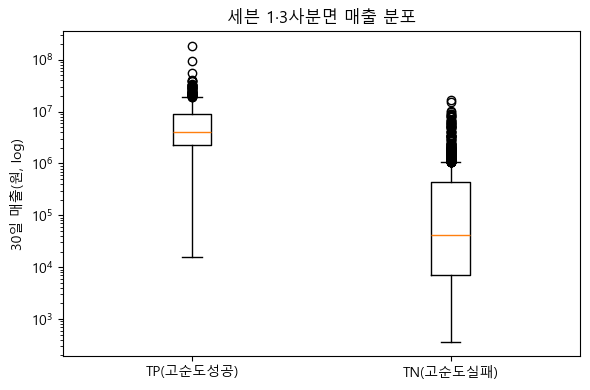

=== 인스타 1·3사분면 좋아요합 상위 30 ===


,ITEM_NM,도메인,좋아요합,pred_success_prob,분류
3018,TXT별모아초코별,CU,82883,0.958,TP
3017,TXT별모아줄줄이미니별,CU,81273,0.951,TP
3016,TXT별모아젤리별,CU,78004,0.964,TP
3020,TXT별모아쿠키별,CU,78004,0.959,TP
4260,라더소세지피자빵,GS25,56550,0.973,TP
4222,데이지에일,GS25,48252,0.951,TP
3346,먹산생크림빵,CU,42136,0.976,TP
4513,서울우유우유크림빵,GS25,40829,0.960,TP
4962,픽셀리라파게티,GS25,39209,0.975,TP
3050,가나디바나나우유,CU,35851,0.980,TP


=== 인스타 1·3사분면 좋아요합 하위 30 ===


,ITEM_NM,도메인,좋아요합,pred_success_prob,분류
4267,랩노쉬블랙페퍼치킨덮밥,GS25,-1,0.038,TN
4266,랩노쉬데리야끼포크덮밥,GS25,-1,0.069,TN
3573,시나모롤초계국수,CU,55,0.001,TN
4102,가또네그로카르미네르,GS25,98,0.160,TN
4944,프론테라버터리샤도네이,GS25,98,0.199,TN
4626,알타감마레세르바까베르네소비뇽,GS25,98,0.066,TN
783,CJ)작은햇반발아현미밥130g,세븐인스타,100,0.032,TN
4308,립서비스까베르네쇼비뇽2022,GS25,103,0.002,TN
4806,청명주세트,GS25,109,0.046,TN
4395,바나나맛우유,GS25,116,0.134,TN


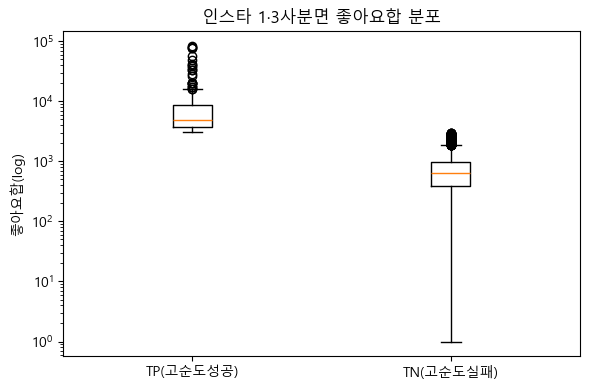

In [36]:
# [Phase 0.5 · Cell 3] 1·3사분면 제품 — 매출(세븐) / 좋아요합(인스타) 상위·하위 30
q13 = CMDF[CMDF["사분면"].isin(["TP(1사분면)", "TN(3사분면)"])].copy()
q13["분류"] = np.where(q13["y_true"] == 1, "TP", "TN")

def _fmt_amt(x):
    if pd.isna(x): return "-"
    if x < 10000: return f"{x:,.0f}원"
    return f"{x/10000:,.0f}만원"

# ── 세븐 매출 상위 30 / 하위 30 ──
sev = q13[q13["중분류"].notna()].copy()

sev_top = sev.sort_values("sales_30d_amt", ascending=False).head(30)
show_t = sev_top[["ITEM_NM", "중분류", "sales_30d_amt", "pred_success_prob", "분류"]].copy()
show_t["매출"] = show_t.pop("sales_30d_amt").map(_fmt_amt)
show_t["pred_success_prob"] = show_t["pred_success_prob"].round(3)
print("=== 세븐 1·3사분면 매출 상위 30 ===")
display(show_t)

sev_bot = sev.sort_values("sales_30d_amt", ascending=True).head(30)
show_b = sev_bot[["ITEM_NM", "중분류", "sales_30d_amt", "pred_success_prob", "분류"]].copy()
show_b["매출"] = show_b.pop("sales_30d_amt").map(_fmt_amt)
show_b["pred_success_prob"] = show_b["pred_success_prob"].round(3)
print("=== 세븐 1·3사분면 매출 하위 30 ===")
display(show_b)

fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot([sev[sev["분류"] == c]["sales_30d_amt"].clip(lower=1) for c in ["TP", "TN"]])
ax.set_xticks([1, 2]); ax.set_xticklabels(["TP(고순도성공)", "TN(고순도실패)"])
ax.set_yscale("log"); ax.set_ylabel("30일 매출(원, log)")
ax.set_title("세븐 1·3사분면 매출 분포"); plt.tight_layout(); plt.show()

# ── 인스타 좋아요합 상위 30 / 하위 30 ──
ins = q13[q13["중분류"].isna()].copy()

ins_top = ins.sort_values("좋아요합", ascending=False).head(30)
show2_t = ins_top[["ITEM_NM", "도메인", "좋아요합", "pred_success_prob", "분류"]].copy()
show2_t["좋아요합"] = show2_t["좋아요합"].round(0).astype("Int64")
show2_t["pred_success_prob"] = show2_t["pred_success_prob"].round(3)
print("=== 인스타 1·3사분면 좋아요합 상위 30 ===")
display(show2_t)

ins_bot = ins.sort_values("좋아요합", ascending=True).head(30)
show2_b = ins_bot[["ITEM_NM", "도메인", "좋아요합", "pred_success_prob", "분류"]].copy()
show2_b["좋아요합"] = show2_b["좋아요합"].round(0).astype("Int64")
show2_b["pred_success_prob"] = show2_b["pred_success_prob"].round(3)
print("=== 인스타 1·3사분면 좋아요합 하위 30 ===")
display(show2_b)

fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot([ins[ins["분류"] == c]["좋아요합"].clip(lower=1) for c in ["TP", "TN"]])
ax.set_xticks([1, 2]); ax.set_xticklabels(["TP(고순도성공)", "TN(고순도실패)"])
ax.set_yscale("log"); ax.set_ylabel("좋아요합(log)")
ax.set_title("인스타 1·3사분면 좋아요합 분포"); plt.tight_layout(); plt.show()

### 2·4사분면(FN·FP) 오분류 진단 — "모델이 왜 틀렸나"

> **FN**(2사분면, 실성공·예측실패 = 놓친 히트) · **FP**(4사분면, 실실패·예측성공 = 속은 케이스)를
> 매출/좋아요 · 카테고리 · **1-hop(키워드·IP)** 으로 해부해 오분류 원인을 규명한다.
>
> **가설** — FN: ① 콜드노드(그래프 연결 빈약) ② 지뢰 키워드 보유 ③ 저성공 카테고리 ④ 인스타 채널 미반영
> / FP: ① 킬러·트렌드 키워드 과신 ② 강한 IP 과신 ③ 무색무취 허브 키워드.
>
> - **Cell 4a**: 킬러🔥·지뢰💣·트렌드📈 키워드 **정의**(성공보유율 장부, 리스트 출력)
> - **Cell 4b**: 1-hop 피처 빌드(`DIAG`) + 오분류 개수·크기·카테고리 prior·확신도
> - **Cell 4c**: 2·4사분면 **매출/좋아요 하위순** (FP=최악 플롭 / FN=작은 성공, 분리 출력)
> - **Cell 4d**: 1-hop 구조 비율 프로파일 (FN vs TP, FP vs TN) — 가설 정량 검증
> - **Cell 4e**: 극단 오분류 케이스 스터디 — 실제 제품·1-hop 키워드(킬러🔥/지뢰💣)·IP
>
> 킬러/지뢰 장부는 Phase 1-0 이전이라 Cell 4a에서 경량 재계산(성공보유/전체보유, min_support>=3, 상·하위 20%).

In [19]:
# [Phase 0.5 · Cell 4a] 킬러·지뢰·트렌드 키워드 정의 (명시적)
# 정의 (Phase 1-0 장부와 동일 방식 — score(k)=성공제품 보유수/전체 보유수; Run-order 위해 인라인):
#   🔥킬러 = score 상위 TOP_PCT% (성공 강연관) / 💣지뢰 = 하위 TOP_PCT% (실패 강연관)
#   📈트렌드 = keyword_nodes.is_trend_keyword
MIN_SUPPORT, TOP_PCT = 3, 20.0
R = f"experiments/results/{EXP}"

pk = pd.read_parquet(f"{R}/weighted_product_keyword_edges.parquet")[["product", "keyword", "attention"]].copy()
pk["attention"] = pk["attention"].astype(float)
pk = pk.drop_duplicates(["product", "keyword"])
pi = pd.read_parquet(f"{R}/weighted_product_ip_edges.parquet")[["product", "ip", "attention"]].copy()
kn = pd.read_parquet("data/processed/hin/keyword_nodes.parquet")
TREND_KW = set(kn.loc[kn["is_trend_keyword"], "keyword"])

# 성공보유율 장부
prod_y = dict(zip(CMDF["ITEM_NM"], CMDF["y_true"]))
pk["y"] = pk["product"].map(prod_y)
ks_ = pk.groupby("keyword").agg(n=("product", "nunique"), succ=("y", "sum"))
ks_ = ks_[ks_["n"] >= MIN_SUPPORT]
ks_["성공보유율"] = ks_["succ"] / ks_["n"]
rk = ks_["성공보유율"].sort_values(ascending=False)
cut = max(1, int(len(rk) * TOP_PCT / 100))
KILLER = set(rk.index[:cut]); LANDMINE = set(rk.index[-cut:]); KW_DEG = ks_["n"].to_dict()
kill_thr = float(rk.iloc[cut - 1]); land_thr = float(rk.iloc[-cut])

print(f"장부 대상 키워드(min_support>={MIN_SUPPORT}): {len(rk)}개  |  킬러·지뢰 각 상·하위 {TOP_PCT:.0f}%")
print(f"\n🔥 킬러 {len(KILLER)}개 (성공보유율 >= {kill_thr:.2f}):")
print("   " + ", ".join(sorted(KILLER, key=lambda k: -rk[k])[:40]) + " …")
print(f"\n💣 지뢰 {len(LANDMINE)}개 (성공보유율 <= {land_thr:.2f}):")
print("   " + ", ".join(sorted(LANDMINE, key=lambda k: rk[k])[:40]) + " …")
print(f"\n📈 트렌드 {len(TREND_KW)}개 (keyword_nodes.is_trend_keyword):")
print("   " + ", ".join(list(TREND_KW)[:40]) + " …")

장부 대상 키워드(min_support>=3): 1222개  |  킬러·지뢰 각 상·하위 20%

🔥 킬러 244개 (성공보유율 >= 0.38):
   로코모코, 꼬깔콘, 여유, 훗카이도, 포카칩, 치로루, 공룡, 가매, 로스, 관람, 슈퍼셀, 일식, 젤리블리, 콜라겐, 도쿄, 주종, 경기장, 하와이, 알포트, 땡초, 응원, 빈츠, 메타몽, 카이막, 박카스, 고창, 누네띠네, 구운, 폭신함, 메이플, 초특가, 띠부씰, 발효, 가을, 녹진함, 핑거, 웰니스, 건더기, 인가, 더킹 …

💣 지뢰 244개 (성공보유율 <= 0.00):
   간바레, 필렛, 브뤼, 스프레소, 윈저, 쿨, 브랜드, 누가, 양상추, 폭스, 파르페, 레시피, 단짠, 고르곤졸라, 카페라떼, 돈, 웨하스, 센쥬, 한과, 피규어, 맥앤치즈, 콜롬비아, 프레첼, 장아찌, 된장, 페어링, 길리안, 뉴룽지, 칸타타, 스모크, 글렌버기, 오믈렛, 용가리, 프레시, 껍질, 레트로, 주류, 랍스터, 냉동, 코어리지 …

📈 트렌드 351개 (keyword_nodes.is_trend_keyword):
   파삭, 맥앤치즈, 된장, 주스, 페어링, 직화, 루이보스, 쫄깃함, 플레인, 담백, 퓨레, 돈코츠, 팝콘, 크래프트, 매콤, 얼그레이, 닭꼬치, 당충전, 간식, 데리야끼, 버섯, 타코야끼, 피스타치오, 옥수수, 샤인머스켓, 잼, 팥, 닭가슴살, 건강, 과자, 비건, 카레, 위스키, 미나리, 새콤, 프라페, 족발, 스무디, 밈, 슴슴함 …


DIAG (5033, 19) | 1-hop 피처 부착 완료

사분면 분포: {'TN(3사분면)': 3454, 'TP(1사분면)': 881, 'FP(4사분면)': 382, 'FN(2사분면)': 316}
도메인 × 오분류:


사분면,FN(2사분면),FP(4사분면)
도메인,,
CU,60,38
GS25,33,31
세븐POS,221,305
세븐인스타,2,8


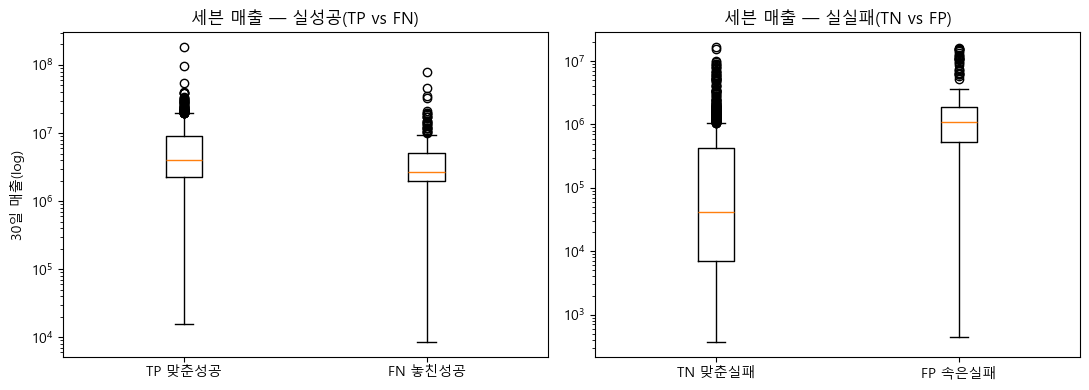

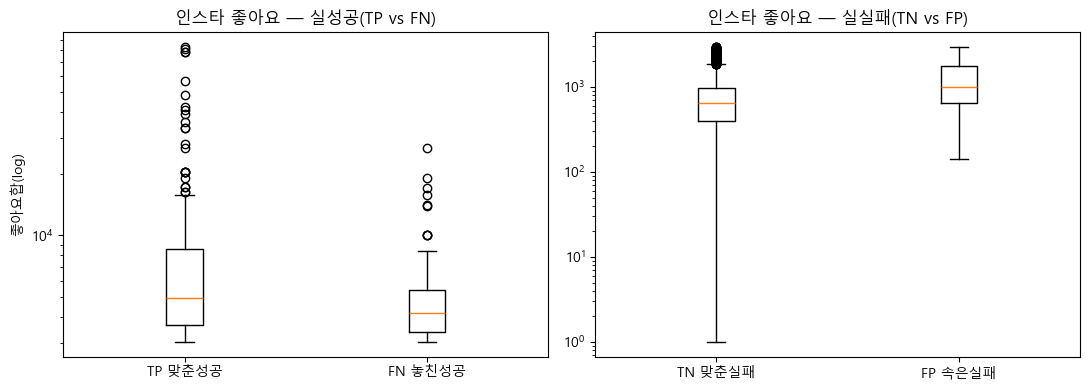


[H3 카테고리 prior] FN 제품의 중분류 평균 실제성공률 0.374 / FP 0.391 (차이 작으면 약한 요인)
[확신도] FN(2사분면): n=316, pred 평균 0.523, 경계오류(|p-THR|<0.1) 40% (나머지는 확신하며 틀림)
[확신도] FP(4사분면): n=382, pred 평균 0.887, 경계오류(|p-THR|<0.1) 36% (나머지는 확신하며 틀림)


In [20]:
# [Phase 0.5 · Cell 4b] 1-hop 피처 빌드 + 오분류 개요·크기·카테고리·확신도
g = pk.groupby("product")
feat = pd.DataFrame({
    "n_kw": g["keyword"].count(),
    "kw_generality": g["keyword"].apply(lambda s: np.mean([KW_DEG.get(k, 0) for k in s])),
    "killer_ratio": g["keyword"].apply(lambda s: np.mean([k in KILLER for k in s])),
    "landmine_ratio": g["keyword"].apply(lambda s: np.mean([k in LANDMINE for k in s])),
    "trend_ratio": g["keyword"].apply(lambda s: np.mean([k in TREND_KW for k in s])),
})
feat["n_ip"] = pi.groupby("product")["ip"].nunique().reindex(feat.index).fillna(0).astype(int)
DIAG = CMDF.merge(feat, left_on="ITEM_NM", right_index=True, how="left")   # ▶ 4c·4d·4e에서 사용
PROD_KWS = {p: sorted(zip(d["keyword"], d["attention"]), key=lambda x: -x[1]) for p, d in pk.groupby("product")}
PROD_IPS = {p: list(d["ip"]) for p, d in pi.groupby("product")}
print(f"DIAG {DIAG.shape} | 1-hop 피처 부착 완료")

print("\n사분면 분포:", {k: int(v) for k, v in DIAG["사분면"].value_counts().items()})
err = DIAG[DIAG["사분면"].str.startswith(("FN", "FP"))]
print("도메인 × 오분류:")
display(err.pivot_table(index="도메인", columns="사분면", values="_id", aggfunc="count", fill_value=0))

def _box(ax, sub, qa, qb, col, labs, title):
    ax.boxplot([sub[sub["사분면"] == q][col].dropna().clip(lower=1) for q in (qa, qb)])
    ax.set_xticks([1, 2]); ax.set_xticklabels(labs); ax.set_yscale("log"); ax.set_title(title)
sev = DIAG[DIAG["중분류"].notna()]; ins = DIAG[DIAG["중분류"].isna()]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
_box(axes[0], sev, "TP(1사분면)", "FN(2사분면)", "sales_30d_amt", ["TP 맞춘성공", "FN 놓친성공"], "세븐 매출 — 실성공(TP vs FN)")
_box(axes[1], sev, "TN(3사분면)", "FP(4사분면)", "sales_30d_amt", ["TN 맞춘실패", "FP 속은실패"], "세븐 매출 — 실실패(TN vs FP)")
axes[0].set_ylabel("30일 매출(log)"); plt.tight_layout(); plt.show()
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
_box(axes[0], ins, "TP(1사분면)", "FN(2사분면)", "좋아요합", ["TP 맞춘성공", "FN 놓친성공"], "인스타 좋아요 — 실성공(TP vs FN)")
_box(axes[1], ins, "TN(3사분면)", "FP(4사분면)", "좋아요합", ["TN 맞춘실패", "FP 속은실패"], "인스타 좋아요 — 실실패(TN vs FP)")
axes[0].set_ylabel("좋아요합(log)"); plt.tight_layout(); plt.show()

catrate = sev.groupby("중분류")["y_true"].mean()
fn_c = sev[sev["사분면"].str.startswith("FN")]["중분류"].map(catrate)
fp_c = sev[sev["사분면"].str.startswith("FP")]["중분류"].map(catrate)
print(f"\n[H3 카테고리 prior] FN 제품의 중분류 평균 실제성공률 {fn_c.mean():.3f} / FP {fp_c.mean():.3f} (차이 작으면 약한 요인)")
DIAG["err_margin"] = (DIAG["pred_success_prob"] - THR).abs()
for q in ["FN(2사분면)", "FP(4사분면)"]:
    sub = DIAG[DIAG["사분면"] == q]
    print(f"[확신도] {q}: n={len(sub)}, pred 평균 {sub['pred_success_prob'].mean():.3f}, "
          f"경계오류(|p-THR|<0.1) {(sub['err_margin'] < 0.1).mean() * 100:.0f}% (나머지는 확신하며 틀림)")

In [ ]:
# [Phase 0.5 · Cell 4c] 2·4사분면(FN·FP) — 매출(세븐)/좋아요(인스타) 순위
# FP(실패인데 성공예측): 상위순  → 모델이 크게 착각한 '큰 플롭' 파악
# FN(성공인데 실패예측): 하위순  → 모델이 못 잡은 '작은 성공' 파악
# ★ 매출 단위: 원(raw). 만원 나눗셈시 1만원 미만→0 반올림 문제 방지.
q24 = DIAG[DIAG["사분면"].isin(["FN(2사분면)", "FP(4사분면)"])].copy()

def _rank(sub, col, unit, ascending=True, n=15):
    t = sub.sort_values(col, ascending=ascending).head(n)
    cat = t["중분류"].where(t["중분류"].notna(), t["도메인"])
    val = t[col].apply(lambda x: f"{x:,.0f}" if pd.notna(x) else "-")
    return pd.DataFrame({"제품": t["ITEM_NM"].values, "카테고리": cat.values,
                         unit: val.values,
                         "pred": t["pred_success_prob"].round(3).values})

sev = q24[q24["중분류"].notna()].copy()
print("=== 세븐 매출 상위 · FP (실패인데 성공예측 = 큰 플롭) ===  [단위: 원]")
display(_rank(sev[sev["y_true"] == 0], "sales_30d_amt", "매출(원)", ascending=False))
print("=== 세븐 매출 하위 · FN (성공인데 실패예측 = 작은 성공) ===  [단위: 원]")
display(_rank(sev[sev["y_true"] == 1], "sales_30d_amt", "매출(원)", ascending=True))

ins = q24[q24["중분류"].isna()].copy()
print("=== 인스타 좋아요합 상위 · FP (실패인데 성공예측) ===")
display(_rank(ins[ins["y_true"] == 0], "좋아요합", "좋아요합", ascending=False))
print("=== 인스타 좋아요합 하위 · FN (성공인데 실패예측) ===")
display(_rank(ins[ins["y_true"] == 1], "좋아요합", "좋아요합", ascending=True))

=== 사분면별 1-hop 구조 피처 평균 ===
(n_kw=키워드수, kw_generality=이웃키워드 평균 보유제품수↑=무색무취 허브, killer/landmine/trend_ratio, n_ip=IP수)


,n_kw,kw_generality,killer_ratio,landmine_ratio,trend_ratio,n_ip
사분면,,,,,,
TP(1사분면),9.020,470.340,0.258,0.000,0.572,0.423
FN(2사분면),8.687,389.201,0.200,0.000,0.563,0.212
TN(3사분면),7.367,334.265,0.094,0.050,0.496,0.186
FP(4사분면),8.209,512.662,0.188,0.013,0.623,0.340



[FN vs TP] 실제성공 — '놓친 것(FN)'이 '맞춘 것(TP)' 대비:
  n_kw            FN    8.687  vs  TP    9.020   ↓
  kw_generality   FN  389.201  vs  TP  470.340   ↓
  killer_ratio    FN    0.200  vs  TP    0.258   ↓
  landmine_ratio  FN    0.000  vs  TP    0.000   ↑
  trend_ratio     FN    0.563  vs  TP    0.572   ↓
  n_ip            FN    0.212  vs  TP    0.423   ↓
  → 콜드노드(H1)면 n_kw·n_ip↓ / 지뢰(H2)면 landmine_ratio↑

[FP vs TN] 실제실패 — '속은 것(FP)'이 '맞춘 것(TN)' 대비:
  n_kw            FP    8.209  vs  TN    7.367   ↑
  kw_generality   FP  512.662  vs  TN  334.265   ↑
  killer_ratio    FP    0.188  vs  TN    0.094   ↑
  landmine_ratio  FP    0.013  vs  TN    0.050   ↓
  trend_ratio     FP    0.623  vs  TN    0.496   ↑
  n_ip            FP    0.340  vs  TN    0.186   ↑
  → 킬러·트렌드 과신(H1)면 killer_ratio·trend↑ / IP 과신(H2)면 n_ip↑ / 무색무취 허브(H3)면 kw_generality↑


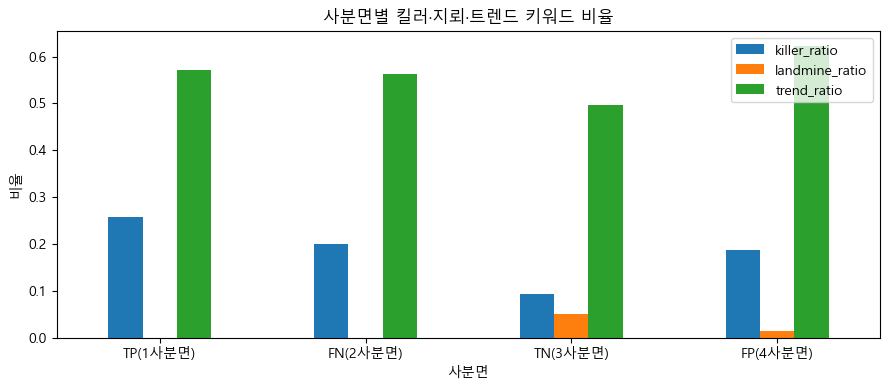

In [22]:
# [Phase 0.5 · Cell 4d] 1-hop 구조 프로파일 — FN vs TP, FP vs TN (가설 정량 검증)
feats = ["n_kw", "kw_generality", "killer_ratio", "landmine_ratio", "trend_ratio", "n_ip"]
order = ["TP(1사분면)", "FN(2사분면)", "TN(3사분면)", "FP(4사분면)"]
prof = DIAG.groupby("사분면")[feats].mean().reindex(order).round(3)
print("=== 사분면별 1-hop 구조 피처 평균 ===")
print("(n_kw=키워드수, kw_generality=이웃키워드 평균 보유제품수↑=무색무취 허브, killer/landmine/trend_ratio, n_ip=IP수)")
display(prof)

fn, tp = prof.loc["FN(2사분면)"], prof.loc["TP(1사분면)"]
fp, tn = prof.loc["FP(4사분면)"], prof.loc["TN(3사분면)"]
print("\n[FN vs TP] 실제성공 — '놓친 것(FN)'이 '맞춘 것(TP)' 대비:")
for f in feats:
    print(f"  {f:15} FN {fn[f]:>8.3f}  vs  TP {tp[f]:>8.3f}   {'↓' if fn[f] < tp[f] else '↑'}")
print("  → 콜드노드(H1)면 n_kw·n_ip↓ / 지뢰(H2)면 landmine_ratio↑")
print("\n[FP vs TN] 실제실패 — '속은 것(FP)'이 '맞춘 것(TN)' 대비:")
for f in feats:
    print(f"  {f:15} FP {fp[f]:>8.3f}  vs  TN {tn[f]:>8.3f}   {'↑' if fp[f] > tn[f] else '↓'}")
print("  → 킬러·트렌드 과신(H1)면 killer_ratio·trend↑ / IP 과신(H2)면 n_ip↑ / 무색무취 허브(H3)면 kw_generality↑")

ax = prof[["killer_ratio", "landmine_ratio", "trend_ratio"]].plot(kind="bar", figsize=(9, 4))
ax.set_title("사분면별 킬러·지뢰·트렌드 키워드 비율"); ax.set_ylabel("비율")
ax.set_xticklabels(prof.index, rotation=0); plt.tight_layout(); plt.show()

In [23]:
# [Phase 0.5 · Cell 4e] 극단 오분류 케이스 스터디 — 1-hop 키워드/IP 직접 확인
N_CASE = 15

def _mag(r):
    if pd.notna(r["중분류"]):
        return f"{r['sales_30d_amt'] / 10000:,.0f}만원" if pd.notna(r["sales_30d_amt"]) else "매출-"
    return f"♥{int(r['좋아요합']):,}" if pd.notna(r["좋아요합"]) else "♥-"

def _kw_tags(prod, topn=8):
    out = []
    for k, a in PROD_KWS.get(prod, [])[:topn]:
        tag = "🔥" if k in KILLER else ("💣" if k in LANDMINE else "")
        out.append(f"{k}{tag}({a:.2f})")
    return " · ".join(out) if out else "(키워드 없음)"

def show_cases(quad, asc, title):
    sub = DIAG[DIAG["사분면"] == quad].sort_values("pred_success_prob", ascending=asc).head(N_CASE)
    print(f"\n{'=' * 72}\n{title} — top {N_CASE}\n{'=' * 72}")
    for _, r in sub.iterrows():
        ips = PROD_IPS.get(r["ITEM_NM"], [])
        ipstr = f"  IP:{','.join(ips)}" if ips else ""
        cat = r["중분류"] if pd.notna(r["중분류"]) else str(r["도메인"])
        print(f"[{cat}] {r['ITEM_NM']}  ({_mag(r)}, pred {r['pred_success_prob']:.3f}){ipstr}")
        print(f"    1-hop: {_kw_tags(r['ITEM_NM'])}")

show_cases("FN(2사분면)", True,  "가장 억울한 FN — 실제 성공인데 pred 최저 (모델이 놓친 히트)")
show_cases("FP(4사분면)", False, "가장 황당한 FP — 실제 실패인데 pred 최고 (모델이 속은 케이스)")
print("\n🔥=킬러 키워드  💣=지뢰 키워드  (괄호=어텐션)  |  성공/실패는 실제 라벨(y_true) 기준")


가장 억울한 FN — 실제 성공인데 pred 최저 (모델이 놓친 히트) — top 15
[GS25] 요아정요거트초코쉘팝팝콘딸  (♥3,458, pred 0.000)  IP:맛삼춘,요아정
    1-hop: 쉘(0.50) · CJ(0.04) · 농심(0.04) · 팝콘(0.03) · 롯데(0.02) · 요거트(0.01) · 딸기🔥(0.00) · 과자(0.00)
[노벨티] 제스)모리나가밀크카라멜모나카97g  (352만원, pred 0.001)
    1-hop: 모나카🔥(0.08) · 일본(0.07) · 밀크(0.02) · 카라멜(0.01) · 디저트(0.00) · 간식(0.00)
[GS25] NCTDREAMXGS25아이돌컴백샌드위치  (♥13,943, pred 0.001)  IP:NCTDREAM
    1-hop: 컴백(0.50) · NCT(0.50) · 아이돌(0.33) · 샌드위치(0.01) · 샌드(0.01) · 빵(0.00)
[CU] 베리초코볼케익  (♥4,202, pred 0.001)
    1-hop: 베리🔥(0.02) · 볼(0.01) · 케이크(0.01) · 초코(0.00) · 부드러움🔥(0.00) · 디저트(0.00) · 달콤(0.00)
[CU] 밀크초코볼케익  (♥4,202, pred 0.002)
    1-hop: 밀크(0.02) · 볼(0.01) · 케이크(0.01) · 우유(0.00) · 초코(0.00) · 부드러움🔥(0.00) · 디저트(0.00) · 달콤(0.00)
[GS25] 젼언니과일모양프룻팝스  (♥7,970, pred 0.002)  IP:젼언니,프룻팝스
    1-hop: 과즙(0.11) · 모양(0.03) · 포도(0.02) · 망고🔥(0.02) · 복숭아(0.01) · 과일(0.00) · 딸기🔥(0.00) · 디저트(0.00)
[GS25] 로로멜로소금팝아이스브륄레  (♥3,347, pred 0.002)  IP:넷플릭스,케이팝데몬헌터스
    1-hop: 로로멜로(0.13) · 팝(0.09) · 브륄레(0.06) · 소금🔥(

## Phase 1-0. 킬러(Killer) / 지뢰(Landmine) 키워드 기준 확정

> 두 버전의 성공 지향(C3) 및 노이즈(C6) 지표를 동일한 잣대로 공정하게 평가하기 위해, 기준이 되는 **킬러(성공 기여) 키워드**와 **지뢰(실패 유발) 키워드**를 먼저 추출하고 검증하여 확정합니다.
> 아래 코드 셀에서 자동으로 추출된 키워드 목록을 보고 수동으로 추가/제외 조정할 수 있습니다.

In [24]:
# ── 킬러/지뢰 키워드 기준 자동 추출 및 수동 확정 ──
import experiments.walk_compare as wc

# 1. 장부 추출 기준 버전 및 파라미터 설정
BASE_EXP_NAME = "exp22_2hop_kw3"
LEDGER_TOP_PCT = 20.0   # 상위/하위 % 범위
MIN_SUPPORT = 3        # 최소 등장 제품 수 (오버핏 방지)

base_D = wc.load_version(BASE_EXP_NAME)
scores, auto_killer, auto_landmine = wc.build_ledger(base_D, top_pct=LEDGER_TOP_PCT, min_support=MIN_SUPPORT)

# 2. 수동 조정 (Override) — 필요 시 튜닝 결과에 따라 추가/제거
REMOVE_FROM_KILLER = set()   # 킬러에서 제외할 단어 (예: {'특정브랜드'})
ADD_TO_KILLER = set()        # 킬러에 강제로 추가할 단어

REMOVE_FROM_LANDMINE = set() # 지뢰에서 제외할 단어
ADD_TO_LANDMINE = set()      # 지뢰에 강제로 추가할 단어

# 최종 확정
KILLER_KWS = (set(auto_killer) - REMOVE_FROM_KILLER) | ADD_TO_KILLER
LANDMINE_KWS = (set(auto_landmine) - REMOVE_FROM_LANDMINE) | ADD_TO_LANDMINE

print(f"=== 킬러 키워드 확정 ({len(KILLER_KWS)}개, 기준: {BASE_EXP_NAME}) ===")
print(sorted(list(KILLER_KWS)))
print(f"\n=== 지뢰 키워드 확정 ({len(LANDMINE_KWS)}개, 기준: {BASE_EXP_NAME}) ===")
print(sorted(list(LANDMINE_KWS)))

=== 킬러 키워드 확정 (244개, 기준: exp22_2hop_kw3) ===
['2026', 'PEACEMINUSONE', 'PLAVE', '가나', '가매', '가을', '건더기', '게', '경기장', '고구마', '고소', '고창', '공룡', '관람', '광천', '구운', '군', '그래놀라', '그린티', '그릴리', '깐풍기', '깔끔', '깔라만시', '껌', '꼬깔콘', '꼬북칩', '꿀', '난', '납작', '너구리', '녹음', '녹진함', '누네띠네', '누들', '다이스', '단', '닭갈비', '담백', '당면', '대게', '더킹', '데이', '데이지', '도쿄', '돈까스', '두바이', '드럼스틱', '딥', '딥앤로우', '딱지장', '딸기', '땡초', '뚱카롱', '띠부씰', '라이트', '랑그드샤', '레드벨벳', '로스', '로코모코', '롤케이크', '마파', '말랑함', '말이', '말차', '맛자랑', '맛장우', '망고', '맥스봉', '머핀', '메밀', '메이플', '메타몽', '멸균', '명란', '명장', '모나카', '몬스터', '몰리두커', '무스', '묵직함', '미각', '미노리', '미역', '박카스', '반숙', '발효', '밥도둑', '배', '버블', '버섯', '베노프', '베리', '베지', '벽돌', '별', '보름달', '볼케이노', '부드러움', '브라우니', '브레드', '비건', '비타민', '빈츠', '빼빼로', '뻥이요', '뿌셔뿌셔', '사브레', '삼립', '새콤', '생크림', '소금', '소보로', '소이', '솔트', '송이', '쇼콜라', '수험생', '슈거', '슈퍼셀', '스노우', '스웨디시', '스타', '스타벅스', '스팀', '스팸', '슴슴함', '시그니처', '시럽', '시즌', '식감', '쌉싸름함', '쑥', '아침', '안심', '알리오올리오', '알밤', '알싸함', '알포트', '앙리', '액티비아', '야채', '양반', '얼박사', 

## Phase 1. 두 버전 비교 및 최종 채택 (기존 Phase F)

> 엣지값 높은 경로(K-P-K)로 조합 생성 시 **"좋은 네트워크"인지** 두 버전을 대조해 최종 1개를 채택.
> 모듈: `experiments/walk_compare.py` (serve 서빙 백엔드는 안 건드림, 버전별 export 직접 로드).
>
> **[1] 전처리**: ① deg 상위 HUB_PCT% **허브 마스킹**(무색무취 토큰 선제외) ② **킬러/지뢰 장부** — `score(k)=성공제품보유/전체보유`, 상위 LEDGER_TOP_PCT% 킬러·하위 LEDGER_TOP_PCT% 지뢰.
>
> **[2] 정성 기준**:
> - C1 일관성(조합쌍 동시출현↑) / C2 구체성(deg·허브비율↓) / **C3 성공지향(킬러↑·지뢰↓·경유 success↑)** / C4 트렌드 / C6 노이즈(지뢰·파편↓)
> - Rule A 카테고리 앵커(라면·젤리 등 1차명사 ≥1) / Rule B base:trend 밸런스(트렌드 30~40%)
>
> **핵심 질문(F3)**: ip≥1로 IP 엣지를 1만개로 늘리면 → **IP 다양성 확보**(킬러 유지+다양성↑)인가, **노이즈 드리프트**(지뢰↑·일관성↓)인가?

In [25]:
# Phase F0 — 두 버전 로드 + 허브 마스킹 + 공통 킬러/지뢰 장부 연동
import importlib, pandas as pd, numpy as np
import experiments.walk_compare as wc
importlib.reload(wc)
from src.data_builder.build_hetero_data import norm_id

# 수치 조정 파라미터 (여기서 미세조정)
HUB_PCT = 5.0          # 허브 마스킹 비율 (상위 %)

TREND_F = wc.load_trend_kw()
_trend = pd.read_parquet(wc.TREND_PATH)
TREND_ATTRS = {str(t): list(a) for t, a in zip(_trend["트렌드_키워드"], _trend["추출_속성_final"])}

VERS_NAMES = {"exp22(ip≥2)": "exp22_2hop_kw3", "exp31(ip≥1)": "exp31_2hop_kw3_ip1"}
DV, LEDG, VERSIONS = {}, {}, {}
for tag, name in VERS_NAMES.items():
    D = wc.load_version(name)
    D["hub"] = wc.build_hub_mask(D, pct=HUB_PCT)
    D["stop"] = wc.BASE_STOP | D["hub"]
    DV[tag], VERSIONS[tag] = D, (D, D["stop"])
    
    # 1-0단계에서 확정한 공통 킬러/지뢰 키워드로 장부 강제 연동 (정량 지표의 공정한 잣대 마련)
    v_scores, _, _ = wc.build_ledger(D, top_pct=LEDGER_TOP_PCT, min_support=MIN_SUPPORT)
    LEDG[tag] = (v_scores, KILLER_KWS, LANDMINE_KWS)
    print(f"{tag}: 키워드 {len(D['graph_kw'])} | 허브 {len(D['hub'])} | 킬러(공통) {len(KILLER_KWS)} / 지뢰(공통) {len(LANDMINE_KWS)}")

# IP 보유 제품명 (F3 시드)
_pe = pd.read_parquet(f"{wc.HIN_DIR}/product_ip_edges.parquet")
_pn = pd.read_parquet(f"{wc.HIN_DIR}/product_nodes.parquet")
_id2nm = {norm_id(c): str(n) for c, n in zip(_pn["ITEM_CD"], _pn["ITEM_NM"])}
_ip_names = {_id2nm.get(norm_id(c)) for c in _pe["ITEM_CD"]}
IP_PRODUCTS = sorted(p for p in _ip_names if p and p in DV["exp22(ip≥2)"]["prod2kw"])
SEEDS_F = ["마라", "흑임자", "로제", "딸기", "띠부씰", "산리오", "단백질"]
print(f"IP 보유 제품(F3 시드): {len(IP_PRODUCTS)}")
print("킬러 예 (공통):", list(KILLER_KWS)[:8])
print("지뢰 예 (공통):", list(LANDMINE_KWS)[:8])

c:\Users\송정현\Documents\Projects\박재홍교수님세미나\Projects\20기\7eleven_npd_framework\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


exp22(ip≥2): 키워드 2221 | 허브 112 | 킬러(공통) 244 / 지뢰(공통) 244
exp31(ip≥1): 키워드 2371 | 허브 121 | 킬러(공통) 244 / 지뢰(공통) 244
IP 보유 제품(F3 시드): 1050
킬러 예 (공통): ['빈츠', '핑거', '웰니스', '꿀', '건더기', '알싸함', '소보로', '춘천']
지뢰 예 (공통): ['간바레', '필렛', '스프레소', '쿨', '베어', '누가', '붉은말', '양상추']


In [26]:
# Phase F1 — 조합 샘플 좌우 대조 (사람이 직관 비교)
print("=== F1. 동일 시드 → 두 버전 bundle/path 대조 ===")
_f1 = wc.f1_side_by_side(VERSIONS, SEEDS_F, TREND_ATTRS)
try:
    from IPython.display import display; display(_f1)
except Exception:
    print(_f1.to_string(index=False))

=== F1. 동일 시드 → 두 버전 bundle/path 대조 ===


,시드,[exp22(ip≥2)] 묶음,[exp22(ip≥2)] 경로,[exp31(ip≥1)] 묶음,[exp31(ip≥1)] 경로
0,마라,마라 · 곤약 · 중식 · 자극적 · 가슴 · 닭가슴살,마라 → 곤약 → 닭가슴살 → 가슴,마라 · 곤약 · 중식 · 자극적 · 닭가슴살 · 가슴,마라 → 곤약 → 초 → 비빔
1,흑임자,흑임자 · 공룡 · 묵직함 · 알 · 소보로 · 멜론,흑임자 → 공룡 → 묵직함 → 아삭함,흑임자 · 공룡 · 잠뜰 · 픽셀리 · 후르츠 · 소보로,흑임자 → 공룡 → 잠뜰 → 픽셀리
2,로제,로제 · 떡볶이 · 분식 · 어묵 · 당면 · 납작,로제 → 떡볶이 → 분식 → 어묵,로제 · 떡볶이 · 분식 · 어묵 · 히밥 · 국밥,로제 → 떡볶이 → 분식 → 어묵
3,딸기,딸기 · 베리 · 말랑함 · 망고 · 오렌지 · 사과,딸기 → 베리 → 말랑함 → 망고,딸기 · 헬로키티 · 페스츄리 · 모찌 · 베이크하우스405 · 베이크,딸기 → 헬로키티 → 페스츄리 → 오징어
4,띠부씰,띠부씰 · 관람 · 초특가 · 응원 · 스포츠 · 경기장,띠부씰 → 관람 → 초특가 → 응원,띠부씰 · 응원 · 초특가 · K리그 · 관람 · 스포츠,띠부씰 → 응원 → 스포츠 → 초특가
5,산리오,산리오 · 빼빼로 · 아몬드 · 견과류 · 호두 · 오독오독,산리오 → 빼빼로 → 아몬드 → 견과류,산리오 · 빼빼로 · 아몬드 · 테디베어 · 깔끔 · 빼빼로데이,산리오 → 빼빼로 → 아몬드 → 견과류
6,단백질,단백질 · 프로틴 · 견과류 · 아몬드 · 호두 · 오독오독,단백질 → 프로틴 → 어묵 → 꼬치,단백질 · 프로틴 · 이정후 · 띠부씰 · 응원 · 초특가,단백질 → 프로틴 → 이정후 → 띠부씰


In [27]:
# Phase F2 — 정량 지표 (C1~C6 + Rule A/B), 시드 평균
print("=== F2. 정량 지표 비교 ===")
_f2 = wc.f2_quant_table(VERSIONS, SEEDS_F, TREND_ATTRS, TREND_F, LEDG)
try:
    from IPython.display import display; display(_f2)
except Exception:
    print(_f2.to_string())
print("\n해석: C1 일관성↑·C3 경유성공도↑·C3 킬러↑·지뢰↓·C6 노이즈↓ = 좋은 네트워크")
print("      RuleA 앵커충족·RuleB 밸런스충족 높을수록 '기획서 작성 가능한' 조합")

=== F2. 정량 지표 비교 ===


,exp22(ip≥2),exp31(ip≥1)
C1_일관성,3.438,3.019
C2_평균deg,35.071,29.595
C2_허브비율,0.048,0.048
C3_킬러비율,0.357,0.333
C3_지뢰비율,0.000,0.000
C3_경유성공도,0.614,0.765
C4_트렌드비율,0.452,0.286
C6_노이즈비율,0.000,0.000
RuleA_앵커충족,0.143,0.143
RuleB_밸런스충족,0.143,0.571



해석: C1 일관성↑·C3 경유성공도↑·C3 킬러↑·지뢰↓·C6 노이즈↓ = 좋은 네트워크
      RuleA 앵커충족·RuleB 밸런스충족 높을수록 '기획서 작성 가능한' 조합


In [28]:
# Phase F3 — IP 경유 분석 (두 버전 핵심 차이 판정)
print("=== F3. IP 보유 제품 시드 → 조합 다양성·품질 ===")
_f3 = wc.f3_ip_analysis(VERSIONS, IP_PRODUCTS, TREND_ATTRS, TREND_F, LEDG, n_sample=300)
try:
    from IPython.display import display; display(_f3)
except Exception:
    print(_f3.to_string())
print("\n판정: ip≥1(exp31)이 [다양성↑ & 킬러 유지 & 지뢰↓] → IP 다양성 확보(채택 근거)")
print("      [지뢰↑ or 일관성↓ or 동일조합 반복(다양성↓)] → 노이즈 드리프트(exp22 유지)")

=== F3. IP 보유 제품 시드 → 조합 다양성·품질 ===


,exp22(ip≥2),exp31(ip≥1)
생성 조합수,285.000,296.000
고유키워드 다양성,0.355,0.373
평균 킬러비율,0.289,0.240
평균 지뢰비율,0.041,0.034
평균 일관성(C1),2.000,1.900



판정: ip≥1(exp31)이 [다양성↑ & 킬러 유지 & 지뢰↓] → IP 다양성 확보(채택 근거)
      [지뢰↑ or 일관성↓ or 동일조합 반복(다양성↓)] → 노이즈 드리프트(exp22 유지)


## Phase F4 — 최종 결정표 (수기)

각 기준별 두 버전 점수(F1~F3 출력) 기입 후 우세 표시.

| 기준 | exp22 (ip≥2) | exp31 (ip≥1) | 우세 |
|---|---|---|---|
| C1 일관성 | | | |
| C2 구체성 (deg·허브) | | | |
| C3 성공지향 (킬러↑·지뢰↓·경유성공↑) | | | |
| C4 트렌드 비율 | | | |
| C6 노이즈 비율 | | | |
| Rule A 카테고리 앵커 | | | |
| Rule B base:trend 밸런스 | | | |
| **F3 IP 다양성·품질** ★ | | | |

### ✅ 최종 채택: ________________  (이 버전으로 serving export → walk 시각화)

- **라벨 기준(PR-AUC)**: exp22 **0.6852** > exp31 0.6753 → 라벨은 exp22 우세.
- **정성 채택 근거** (라벨을 뒤집을 만한 추천 품질 차이가 있으면 기입):
- **결정**: PR-AUC·정성 둘 다 exp22면 exp22 / F3에서 exp31의 IP 다양성이 의미있게 우수하면 재고.

## Phase 2-1. walk 분석 — 일관묶음 vs 탐색경로, 스텝수 드리프트 (기존 Phase A)

선택된 최종 모델 버전을 기준으로 walk 심층 분석을 진행합니다.

In [29]:
# ── Phase 2. 최종 채택된 모델로 메인 분석 환경 전환 ──
# F4 최종 채택 결과에 따라 아래 CHOSEN_EXP 값을 변경하여 메인 분석 대상을 설정하세요.
CHOSEN_EXP = "exp22_2hop_kw3"  # 예: 'exp22_2hop_kw3' (ip≥2) 또는 'exp31_2hop_kw3_ip1' (ip≥1)

import src.eval.serve as serve
serve.SERVING_EXP = CHOSEN_EXP
serve._data.cache_clear()  # 기존 캐시 초기화

# 데이터셋 재로드 및 분석용 전역변수 업데이트
import pandas as pd
kn = pd.read_parquet("data/processed/hin/keyword_nodes.parquet")
TREND_KW = set(kn.loc[kn["is_trend_keyword"], "keyword"])
D = serve._data()
prod_succ = dict(zip(D["scores"]["ITEM_NM"], D["scores"]["y_true"]))
SUCC = [p for p in D["prod2kw"] if prod_succ.get(p) == 1]
FAIL = [p for p in D["prod2kw"] if prod_succ.get(p) == 0]
KW_OF = {p: set(k for k, _ in lst) for p, lst in D["prod2kw"].items()}
SEEDS = [s for s in ["마라", "흑임자", "로제", "단백질", "딸기", "띠부씰", "감자", "매콤"] if s in D["graph_kw"]]

print(f"[임포트 완료] 분석용 메인 모델이 '{serve.SERVING_EXP}'로 전환되었습니다.")
print(f"성공 제품: {len(SUCC)}개 | 실패 제품: {len(FAIL)}개 | 트렌드키워드: {len(TREND_KW)}개\n")

# ── Phase A. walk 분석: 일관묶음 vs 탐색경로, 스텝수 드리프트 진단 ──
print("① 일관 묶음(bundle) vs ② 탐색 경로(paths) — 스텝별\n")
for seed in SEEDS[:4]:
    attrs = serve.infer_attrs(seed) or [seed]
    bundle = serve.recommend_bundle(attrs)
    print(f"[{seed}] 묶음: {bundle}")
    for st in [2, 3, 4]:
        ps = serve.recommend_paths(attrs, max_steps=st, n_paths=2, avoid=bundle)
        for p, _ in ps:
            print(f"   {st}스텝: " + " → ".join(p))
    print()

# 드리프트 지표: 스텝별 경로 키워드의 (a)신규율 (b)평균 제품빈도(=일반성)
print("스텝별 드리프트 진단 (전 시드 평균):")
print(f"{'스텝':>4}{'신규키워드율':>12}{'평균 제품빈도':>13}  (빈도↑=일반어로 드리프트)")
for st in [2, 3, 4]:
    new_r, gen = [], []
    for seed in SEEDS:
        attrs = serve.infer_attrs(seed) or [seed]
        bundle = set(serve.recommend_bundle(attrs))
        for p, _ in serve.recommend_paths(attrs, max_steps=st, n_paths=3, avoid=list(bundle)):
            kws = p[1:]
            if kws:
                new_r.append(np.mean([k not in bundle for k in kws]))
                gen.append(np.mean([D["deg"].get(k, 0) for k in kws]))
    print(f"{st:>4}{np.mean(new_r):>12.2f}{np.mean(gen):>13.0f}")
print("→ 신규율 높고 빈도 적당하면 좋은 탐색 / 빈도 급증하면 일반어 드리프트 (스텝 줄일 신호)")


[임포트 완료] 분석용 메인 모델이 'exp22_2hop_kw3'로 전환되었습니다.
성공 제품: 1197개 | 실패 제품: 3835개 | 트렌드키워드: 351개

① 일관 묶음(bundle) vs ② 탐색 경로(paths) — 스텝별

[마라] 묶음: ['감칠맛', '마라', '매콤', '쫄깃함', '달콤', '고소']
   2스텝: 감칠맛 → 미노리 → 키친
   2스텝: 감칠맛 → 대게 → 딱지장
   3스텝: 감칠맛 → 개성 → 촉촉 → 도쿄
   3스텝: 감칠맛 → 개성 → 매콤 → 볼케이노
   4스텝: 감칠맛 → 개성 → 촉촉 → 도쿄 → 브레드
   4스텝: 감칠맛 → 개성 → 매콤 → 관람 → 경기장

[흑임자] 묶음: ['간식', '견과류', '달콤', '부드러움', '고소', '바삭']
   2스텝: 간식 → 관람 → 경기장
   2스텝: 간식 → 도쿄 → 브레드
   3스텝: 간식 → 관람 → 응원 → 경기장
   3스텝: 간식 → 관람 → 띠부씰 → 경기장
   4스텝: 간식 → 관람 → 경기장 → 콜라보 → 슴슴함
   4스텝: 간식 → 관람 → 경기장 → 콜라 → 슴슴함

[로제] 묶음: ['크림', '부드러움', '달콤', '빵', '촉촉', '고소']
   2스텝: 크림 → 주종 → 발효
   2스텝: 크림 → 커스터드 → 카스타드
   3스텝: 크림 → 생크림 → 응원 → 경기장
   3스텝: 크림 → 생크림 → 응원 → 관람
   4스텝: 크림 → 생크림 → 응원 → 관람 → 경기장
   4스텝: 크림 → 생크림 → 스포츠 → 관람 → 경기장

[단백질] 묶음: ['단백질', '닭가슴살', '닭', '가슴', '부드러움', '달콤']
   2스텝: 단백질 → 베노프 → 청키
   2스텝: 단백질 → 베노프 → 피넛
   3스텝: 단백질 → 베노프 → 바 → 딥앤로우
   3스텝: 단백질 → 베노프 → 쫀득함 → 치로루
   4스텝: 단백질 → 베노프 → 달콤 → 홀릭 → 스타일
   4스텝: 단백질 → 베노프 → 달콤 → 홀릭 

## Phase 2-2. 트렌드 키워드 비율 — 성공 vs 실패 (기존 Phase B)

,구분,트렌드KW 비율(전체),제품당 트렌드비율(평균),제품당 트렌드KW수
0,성공,0.568,0.570,5.07
1,실패,0.509,0.508,3.80



→ 성공/실패 트렌드비율 비율(lift) = 1.12  (>1이면 성공 제품이 트렌드 키워드를 더 많이 보유)


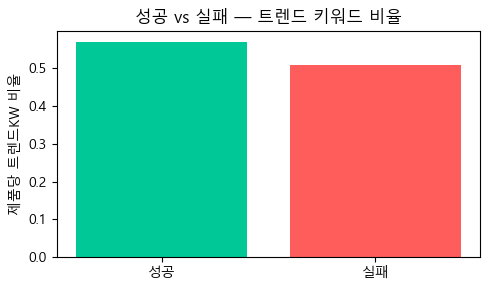

In [30]:
# ── Phase B. 성공/실패 제품 주변 키워드의 트렌드 키워드 비율 ──
def trend_stats(prods):
    tot, tr, per = 0, 0, []
    for p in prods:
        kws = [k for k, _ in D["prod2kw"][p]]
        if not kws:
            continue
        t = sum(k in TREND_KW for k in kws)
        tot += len(kws); tr += t; per.append(t / len(kws))
    return tr / max(tot, 1), float(np.mean(per)), float(np.mean([len([k for k,_ in D["prod2kw"][p] if k in TREND_KW]) for p in prods]))

sr, sp, sc = trend_stats(SUCC)
fr, fp, fc = trend_stats(FAIL)
df = pd.DataFrame({
    "구분": ["성공", "실패"],
    "트렌드KW 비율(전체)": [f"{sr:.3f}", f"{fr:.3f}"],
    "제품당 트렌드비율(평균)": [f"{sp:.3f}", f"{fp:.3f}"],
    "제품당 트렌드KW수": [f"{sc:.2f}", f"{fc:.2f}"],
})
try:
    from IPython.display import display; display(df)
except Exception:
    print(df.to_string(index=False))
print(f"\n→ 성공/실패 트렌드비율 비율(lift) = {sr/max(fr,1e-9):.2f}  (>1이면 성공 제품이 트렌드 키워드를 더 많이 보유)")
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(["성공", "실패"], [sp, fp], color=["#00C896", "#FF5C5C"])
ax.set_ylabel("제품당 트렌드KW 비율"); ax.set_title("성공 vs 실패 — 트렌드 키워드 비율"); plt.tight_layout(); plt.show()


## Phase 2-3. 네트워크 허브 키워드 (중심성) (기존 Phase C)

In [31]:
# ── Phase C. 네트워크 허브 키워드 (중심성) ──
# 키워드 동시출현 그래프 (제품 매개) → degree / eigenvector 중심성
coc = defaultdict(int)
for p, lst in D["prod2kw"].items():
    ks = [k for k, _ in lst]
    for a in range(len(ks)):
        for b in range(a + 1, len(ks)):
            coc[tuple(sorted((ks[a], ks[b])))] += 1
G = nx.Graph()
for (a, b), w in coc.items():
    if w >= 3:                              # 노이즈 제거 임계
        G.add_edge(a, b, weight=w)
print(f"동시출현 그래프: 노드 {G.number_of_nodes()} / 엣지 {G.number_of_edges()}")

# 최대 연결요소에서 eigenvector 중심성
Gc = G.subgraph(max(nx.connected_components(G), key=len)).copy()
eig = nx.eigenvector_centrality_numpy(Gc, weight="weight")
deg_c = {k: D["deg"].get(k, 0) for k in G.nodes}      # 제품빈도(인기 허브)
cooc_deg = dict(G.degree())                            # 연결 키워드 수(커넥터 허브)

def top(dct, n=15):
    return sorted(dct.items(), key=lambda x: -x[1])[:n]

print("\n[degree 허브 — 제품 많이 보유]:", [k for k, _ in top(deg_c, 10)])
print("[connector 허브 — 많은 키워드와 동시출현]:", [k for k, _ in top(cooc_deg, 10)])
print("[eigenvector 허브 — 중심부 연결]:", [k for k, _ in top(eig, 10)])
HUBS = [k for k, _ in top(eig, 30)]      # Phase D 에서 사용할 허브 집합 (eigenvector 기준)


동시출현 그래프: 노드 1095 / 엣지 10791

[degree 허브 — 제품 많이 보유]: ['간식', '달콤', '야식', '디저트', '부드러움', '고소', '식사', '초코', '크림', '빵']
[connector 허브 — 많은 키워드와 동시출현]: ['간식', '달콤', '야식', '식사', '부드러움', '디저트', '고소', '간편', '크림', '매콤']
[eigenvector 허브 — 중심부 연결]: ['간식', '달콤', '부드러움', '디저트', '고소', '야식', '크림', '초코', '바삭', '빵']


## Phase 2-4. 허브 포함 여부 — 성공 vs 실패 비교 (기존 Phase D)

,허브,성공포함율,실패포함율,lift,제품수
26,한정,0.085,0.018,4.74,171
23,시즌,0.094,0.025,3.74,208
13,촉촉,0.104,0.037,2.84,266
19,식감,0.088,0.032,2.76,227
2,부드러움,0.243,0.103,2.35,687
10,짭조름함,0.122,0.057,2.15,364
4,고소,0.185,0.089,2.07,563
24,새콤,0.063,0.031,2.06,194
20,딸기,0.072,0.036,2.01,223
16,쫀득함,0.084,0.047,1.79,282



제품당 평균 허브 키워드 수 — 성공 4.09 / 실패 2.58 (lift 1.58)
→ lift>1 이면 성공 제품이 허브 키워드를 더 많이 포함 = '허브 포함이 성공과 연관'


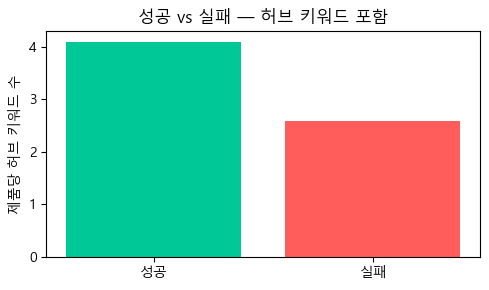

In [32]:
# ── Phase D. 허브 키워드 포함 여부 — 성공 vs 실패 비교 ──
succ_sets = [KW_OF[p] for p in SUCC]
fail_sets = [KW_OF[p] for p in FAIL]

rows = []
for h in HUBS:
    sf = np.mean([h in s for s in succ_sets])
    ff = np.mean([h in s for s in fail_sets])
    rows.append({"허브": h, "성공포함율": round(sf, 3), "실패포함율": round(ff, 3),
                 "lift": round(sf / (ff + 1e-9), 2), "제품수": D["deg"].get(h, 0)})
hub_df = pd.DataFrame(rows).sort_values("lift", ascending=False)
try:
    from IPython.display import display; display(hub_df.head(20))
except Exception:
    print(hub_df.head(20).to_string(index=False))

# 종합: 제품당 평균 허브 보유 수
hubset = set(HUBS)
s_hub = np.mean([len(s & hubset) for s in succ_sets])
f_hub = np.mean([len(s & hubset) for s in fail_sets])
print(f"\n제품당 평균 허브 키워드 수 — 성공 {s_hub:.2f} / 실패 {f_hub:.2f} (lift {s_hub/max(f_hub,1e-9):.2f})")
print("→ lift>1 이면 성공 제품이 허브 키워드를 더 많이 포함 = '허브 포함이 성공과 연관'")
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(["성공", "실패"], [s_hub, f_hub], color=["#00C896", "#FF5C5C"])
ax.set_ylabel("제품당 허브 키워드 수"); ax.set_title("성공 vs 실패 — 허브 키워드 포함"); plt.tight_layout(); plt.show()


## Phase 2-5. 결론 (수기) (기존 Phase E)

### 1. walk 스텝수 (Phase 2-1)

### 2. 트렌드 키워드 (Phase 2-2)

### 3. 허브 키워드 (Phase 2-3·2-4)
